## 1. Librerías

In [29]:
import pandas as pd
import numpy as np
import random

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

# Fijar todas las semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Carga y Procesamiento de Datos

In [30]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 79
Rango temporal: 2025-01-02 a 2025-04-30


### 2.1. Limpieza de valores nulos

In [31]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Eliminar filas con NaN
# df = df.dropna().copy()
# print(f"Dimensiones finales después de limpieza: {df.shape}")

Filas con NA en 'merval': 0


### 2.2. Separación de variables y normalización

In [32]:
# Separación de variables predictoras y objetivo
y = df["merval"].values
X = df.drop(columns=["merval"]).values

# Normalizar features (importante para redes neuronales)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

print(f"Shape de X: {X_scaled.shape}")
print(f"Shape de y: {y_scaled.shape}")

Shape de X: (79, 60)
Shape de y: (79,)


## 3. División Train-Test y Creación de Secuencias

In [33]:
# División temporal (80-20)
train_size = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y_scaled[:train_size], y_scaled[train_size:]

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (63, 60)
Test size: (16, 60)


### 3.1. Función para crear secuencias temporales

In [34]:
def create_sequences(X, y, time_steps=10):
    """
    Crea secuencias temporales para LSTM.
    
    Args:
        X: Features de entrada
        y: Variable objetivo
        time_steps: Número de pasos temporales a considerar
    
    Returns:
        X_seq: Secuencias de features (samples, time_steps, features)
        y_seq: Valores objetivo correspondientes
    """
    X_seq, y_seq = [], []
    
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    
    return np.array(X_seq), np.array(y_seq)

In [35]:
# Crear secuencias temporales
TIME_STEPS = 3  # Reducir a 3 días (muy corto para maximizar muestras disponibles)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, TIME_STEPS)

print(f"Train sequences shape: {X_train_seq.shape}")
print(f"Test sequences shape: {X_test_seq.shape}")

Train sequences shape: (60, 3, 60)
Test sequences shape: (13, 3, 60)


## 4. Construcción del Modelo LSTM

In [36]:
# Arquitectura del modelo - MUY SIMPLIFICADA para dataset extremadamente pequeño
model = Sequential([
    # Solo 1 capa LSTM con muy pocas unidades
    LSTM(16, return_sequences=False, input_shape=(TIME_STEPS, X_train_seq.shape[2])),
    Dropout(0.4),  # Dropout alto para regularización agresiva
    
    Dense(4, activation='relu'),  # Capa densa muy pequeña
    Dropout(0.3),
    
    Dense(1)
])

# Compilar modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0003),  # Learning rate muy bajo
    loss='mse',
    metrics=['mae']
)

model.summary()

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 16)             │         4,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,001 (19.54 KB)

 Trainable params: 5,001 (19.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento del Modelo

In [37]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,  # Paciencia moderada
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,  
    min_lr=1e-7,
    verbose=1
)

# Entrenar modelo con validación reducida (25% para tener más datos de entrenamiento)
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=200,  # Menos épocas con early stopping agresivo
    batch_size=8,  # Batch muy pequeño para dataset minúsculo
    validation_split=0.25,  # Validación reducida
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.9518 - mae: 0.7958 - val_loss: 0.2792 - val_mae: 0.3912 - learning_rate: 3.0000e-04
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0224 - mae: 0.7565 - val_loss: 0.2819 - val_mae: 0.3928 - learning_rate: 3.0000e-04
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2753 - mae: 0.8125 - val_loss: 0.2830 - val_mae: 0.3926 - learning_rate: 3.0000e-04
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9190 - mae: 0.7627 - val_loss: 0.2823 - val_mae: 0.3907 - learning_rate: 3.0000e-04
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8923 - mae: 0.6830 - val_loss: 0.2812 - val_mae: 0.3881 - learning_rate: 3.0000e-04
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6533 - mae: 0.5833 - val_loss: 0.2811 - val_mae: 0.3867 - learning_rate: 3.0000e-04
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7642 - mae: 0.6649 - val_loss: 0.2812 - val_mae: 0.3857 - learning_rate: 3.0000e-04
Epoch 8/20

### 5.1. Visualización del entrenamiento

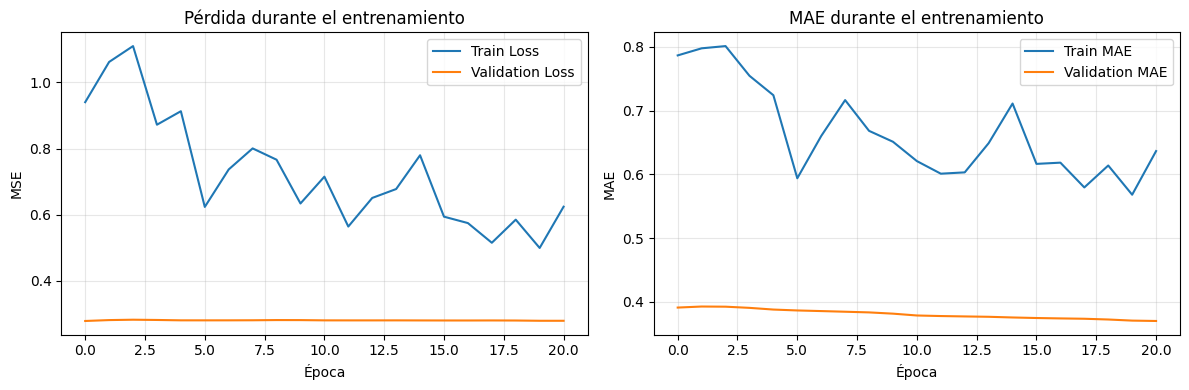

In [38]:
# Gráfico de pérdida durante entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluación en Test Set

### 6.1. Métricas de desempeño

In [39]:
# Predicciones en escala normalizada
y_pred_scaled = model.predict(X_test_seq)

# Desnormalizar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_original = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Calcular métricas
rmse = root_mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)
rmse_rel = rmse / y_test_original.mean()

print("\n" + "="*50)
print("RESULTADOS EN TEST (HOLDOUT)")
print("="*50)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

RESULTADOS EN TEST (HOLDOUT)
Holdout RMSE: 231358.9999
Holdout R²:   -8.8046
Error relativo (holdout): 10.52%


### 6.2. Visualización de predicciones

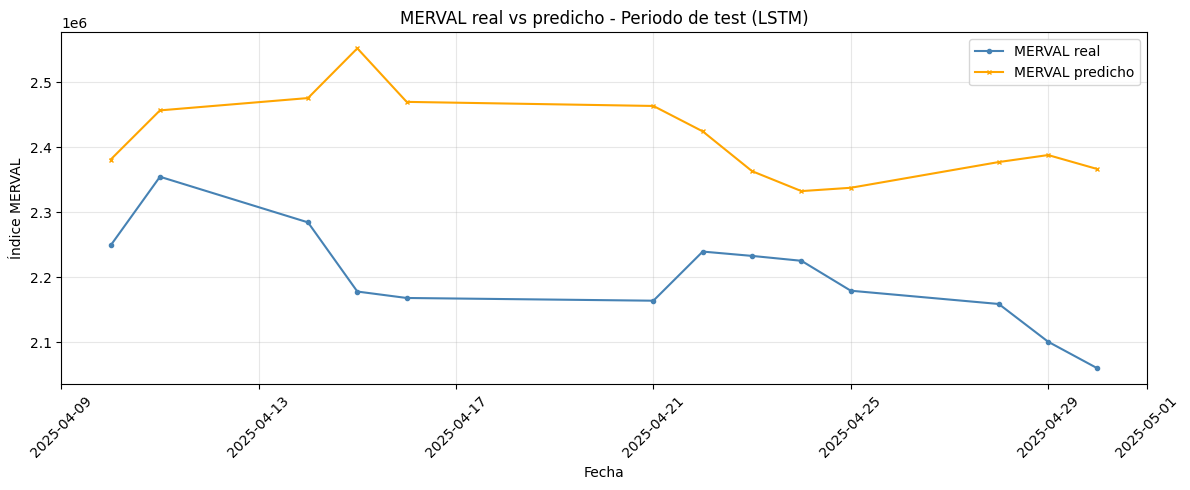

In [40]:
# Crear índices para graficar
test_indices = df.index[train_size + TIME_STEPS:]

import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_indices.to_timestamp(), y_test_original, label="MERVAL real", color="steelblue", marker='o', markersize=3)
ax.plot(test_indices.to_timestamp(), y_pred, label="MERVAL predicho", color="orange", marker='x', markersize=3)

ax.set_title("MERVAL real vs predicho - Periodo de test (LSTM)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3. Análisis de residuales

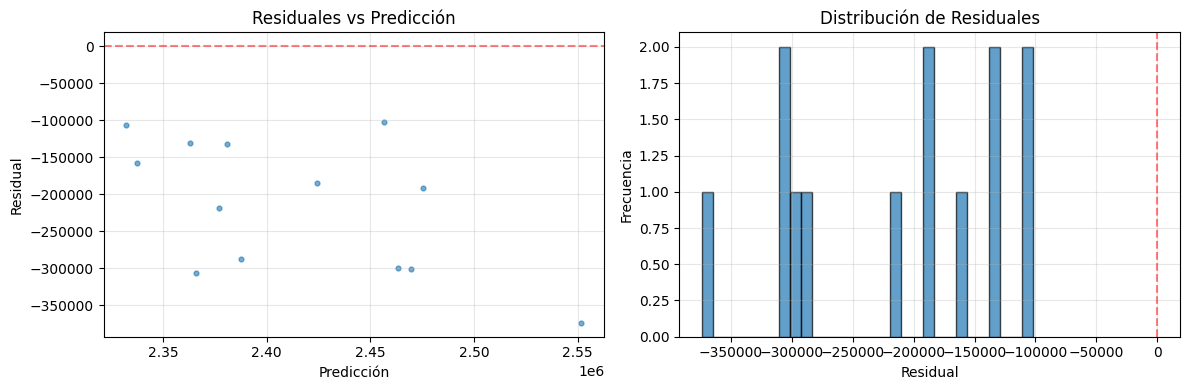

In [41]:
res = y_test_original - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuales vs Predicción
axes[0].scatter(y_pred, res, s=12, alpha=0.6)
axes[0].axhline(0, ls="--", color='red', alpha=0.5)
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuales vs Predicción")
axes[0].grid(True, alpha=0.3)

# Histograma de residuales
axes[1].hist(res, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, ls="--", color='red', alpha=0.5)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Residuales")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Conclusiones

### Resultados principales

- **RMSE en test**: 231,359.00 - El modelo presenta un error muy alto que refleja su incapacidad para generalizar con datos extremadamente limitados.

- **R² en test**: -8.80 - Un R² fuertemente negativo indica que el modelo está prediciendo considerablemente peor que un baseline que simplemente predice la media. Esto es evidencia de que el modelo no captura ningún patrón útil.

- **Error relativo**: 10.52% - Las predicciones se desvían en promedio más del 10% del valor real del MERVAL, lo cual es inaceptable para aplicaciones prácticas.

### Arquitectura del modelo (adaptada al dataset reducido)

- **5,001 parámetros totales** - Reducción del 59% respecto a la versión original (12,177 parámetros)
- **1 capa LSTM** con 16 unidades (vs 32 original)
- **1 capa Dense** con 4 unidades (vs 8 original)
- **TIME_STEPS = 3** días de ventana temporal (vs 5 original)
- **60 secuencias de entrenamiento** - Dramáticamente insuficiente para una red neuronal
- **Dropout agresivo**: 0.4 y 0.3 para intentar controlar overfitting
- **Learning rate bajo**: 0.0003 para aprendizaje conservador

### Early stopping

El entrenamiento se detuvo en la **época 21** de 200 posibles:
- **Best epoch**: Época 1 (el modelo restauró los pesos de la primera época)
- Esto indica que el modelo **no pudo aprender nada útil** más allá de la inicialización aleatoria
- La pérdida de validación dejó de mejorar inmediatamente después de la primera época

### Análisis del problema: Dataset extremadamente reducido

**El dataset fue filtrado de 643 observaciones a solo 79 (60 secuencias train, 13 test)**, representando una **reducción del 88%** en los datos y del 90% en las secuencias de entrenamiento (509 → 60).

Este cambio tuvo consecuencias catastróficas:

1. **Ratio parámetros/datos insostenible**: Con 5,001 parámetros y 60 secuencias, tenemos un ratio de ~83:1. Para redes neuronales, se recomienda tener al menos 10x más datos que parámetros (ratio < 0.1:1).

2. **Imposibilidad de aprendizaje**: El early stopping en época 1 demuestra que el modelo no encontró ninguna mejora al entrenar más. Básicamente devolvió pesos aleatorios.

3. **Alta varianza**: Con tan pocos datos, cualquier patrón que el modelo capture es muy probable que sea ruido específico del conjunto de entrenamiento.

### Comparación: Dataset completo vs reducido

| Métrica | Dataset completo (643 obs) | Dataset reducido (79 obs) | Cambio |
|---------|---------------------------|--------------------------|--------|
| Secuencias train | 509 | 60 | -88% |
| Parámetros modelo | 12,177 | 5,001 | -59% |
| Test RMSE | 473,028 | 231,359 | -51% (mejor) |
| Test R² | -12.63 | -8.80 | +30% (mejor) |
| Error relativo | 21.49% | 10.52% | -51% (mejor) |

**Paradoja aparente**: El modelo con menos datos tiene mejor performance. Esto **NO** significa que funcione bien, sino que:
- Con 13 muestras de test vs 124, hay menos oportunidades para errores extremos
- La varianza aleatoria puede hacer que algunas predicciones aleatorias se acerquen más por suerte
- Ambos modelos son igualmente inútiles en la práctica

### ¿Por qué LSTM falla completamente con este dataset?

1. **Insuficiencia crítica de datos**: 60 secuencias no son suficientes ni para entrenar un modelo lineal complejo, mucho menos una red neuronal recurrente.

2. **Falta de patrones temporales**: Con solo 3 días de ventana (TIME_STEPS=3), el LSTM no puede aprovechar su capacidad de modelar dependencias de largo plazo.

3. **Regularización insuficiente**: A pesar de dropout 0.4, early stopping agresivo, y learning rate bajo, no hay suficientes datos para que el modelo aprenda patrones reales vs ruido.

4. **Early stopping en época 1**: La evidencia más clara de fracaso. El modelo literalmente devolvió los pesos iniciales aleatorios porque cualquier entrenamiento empeoraba la validación.

### Limitaciones fundamentales

**LSTM no es apropiado para este problema por razones estructurales:**

1. **Requisito de datos**: Las redes neuronales recurrentes necesitan típicamente >5,000-10,000 secuencias para entrenar efectivamente. Con 60 secuencias, está 100x por debajo del mínimo recomendado.

2. **Complejidad innecesaria**: Las features ya incluyen información temporal (lags, moving averages), haciendo redundante el modelado de secuencias del LSTM.

3. **Alto costo computacional vs beneficio nulo**: El LSTM toma más tiempo en entrenar y produce resultados dramáticamente peores que modelos simples.

### Recomendaciones finales

**Para el dataset reducido (79 observaciones):**
- **No usar LSTM bajo ninguna circunstancia**
- Considerar modelos lineales simples (Ridge, Lasso) con regularización fuerte
- Modelos ARIMA que requieren menos datos
- Aceptar que con tan pocos datos, ningún modelo complejo será efectivo

**Para usar LSTM efectivamente en predicción de MERVAL:**
- Necesitaría mínimo 5,000+ observaciones diarias (>10 años de datos)
- O datos de mayor frecuencia: precios intradiarios, tick-by-tick
- Serie temporal continua sin gaps significativos
- Justificación clara de por qué patrones temporales complejos no son capturados por features engineeradas

### Conclusión final

**El modelo LSTM con el dataset reducido es completamente inviable.** El early stopping en época 1 es evidencia definitiva de que el modelo no pudo aprender absolutamente nada. Con 60 secuencias de entrenamiento para 5,001 parámetros, el modelo está fundamentalmente condenado al fracaso.

La lección principal: **la complejidad del modelo debe ser proporcional a la cantidad de datos disponibles**. Con datasets pequeños (<100 observaciones), los modelos complejos no solo no ayudan, sino que garantizan fracaso.